In [299]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [300]:
df = pd.read_csv('Social_Network_Ads.csv')

In [301]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [302]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [303]:
df.duplicated().sum()

np.int64(33)

In [304]:
df = df.drop_duplicates().reset_index(drop=True)

In [305]:
print(df.duplicated().sum())
print(f'Shape of the dataset after droppoing duplicate values is ',df.shape)

0
Shape of the dataset after droppoing duplicate values is  (367, 3)


In [306]:
print(df['Purchased'].value_counts(normalize=True))

Purchased
0    0.623978
1    0.376022
Name: proportion, dtype: float64


In [307]:
df.boxplot(column=['Age', 'EstimatedSalary'])

<Axes: >

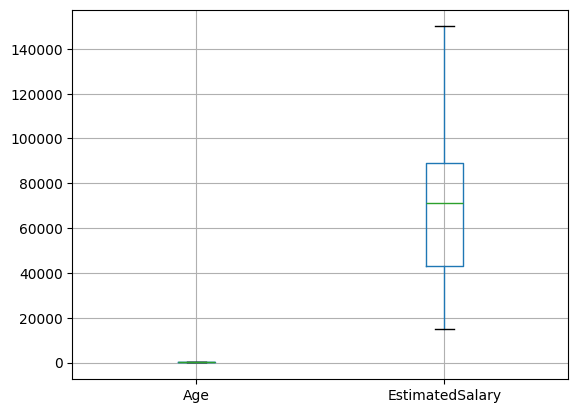

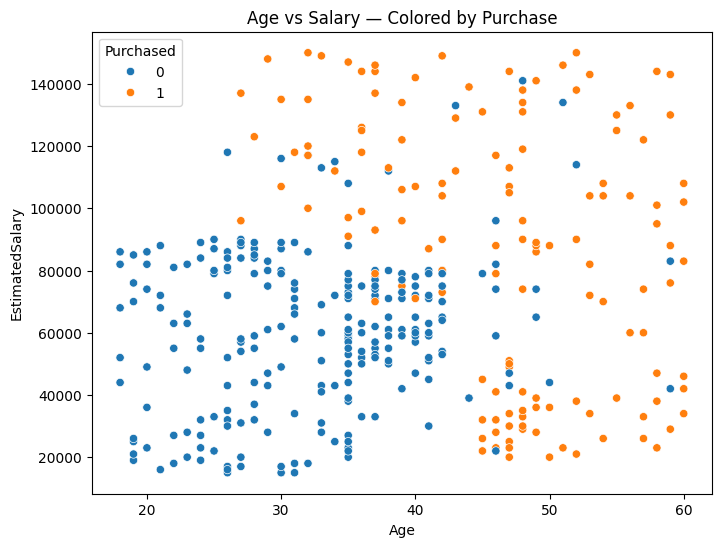

In [308]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Purchased')
plt.title('Age vs Salary — Colored by Purchase')
plt.show()

In [309]:
df['weights']=1/df.shape[0]

In [310]:
df

,Age,EstimatedSalary,Purchased,weights
0,19,19000,0,0.002725
1,35,20000,0,0.002725
2,26,43000,0,0.002725
3,27,57000,0,0.002725
4,19,76000,0,0.002725
...,...,...,...,...
362,46,41000,1,0.002725
363,51,23000,1,0.002725
364,50,20000,1,0.002725
365,36,33000,0,0.002725


In [311]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [312]:
x= df.iloc[:,0:2].values
y= df.iloc[:,2].values

In [313]:
dt1.fit(x,y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

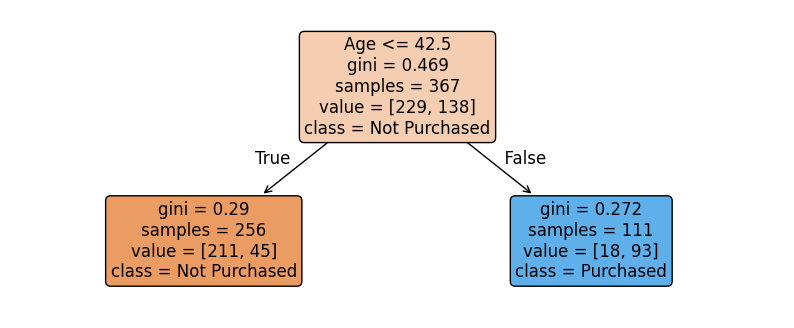

In [314]:

plt.figure(figsize=(10, 4))
plot_tree(dt1, feature_names=['Age', 'EstimatedSalary'], class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True, fontsize=12)
plt.show()

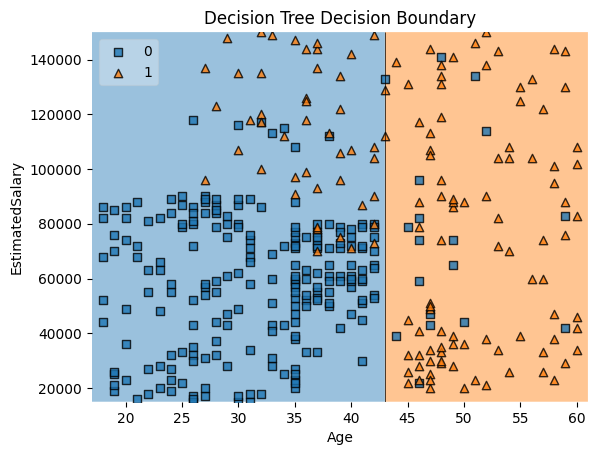

In [315]:
plot_decision_regions(x,y,clf=dt1,legend=2)
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Decision Tree Decision Boundary')
plt.show()

In [316]:
df['y_pred']=dt1.predict(x)

In [317]:
df

,Age,EstimatedSalary,Purchased,weights,y_pred
0,19,19000,0,0.002725,0
1,35,20000,0,0.002725,0
2,26,43000,0,0.002725,0
3,27,57000,0,0.002725,0
4,19,76000,0,0.002725,0
...,...,...,...,...,...
362,46,41000,1,0.002725,1
363,51,23000,1,0.002725,1
364,50,20000,1,0.002725,1
365,36,33000,0,0.002725,0


In [318]:
def calculate_error(df):
    error = df.loc[df['Purchased'] != df['y_pred'], 'weights'].sum()
    return error

In [319]:
calculate_error(df)
print(error)

0.21798365122615798


In [320]:
def calculate_model_weight(error):
    
    return .5*np.log((1-error)/(error+.00000001))

In [321]:
alpha_1=calculate_model_weight(error)
alpha_1

np.float64(0.6387277676053705)

Step 4 : Update Weights

In [322]:
def update_row_weights(row,alpha):
    if row['Purchased']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [323]:
df['updated_weights'] = df.apply(lambda row: update_row_weights(row, alpha_1), axis=1)

In [324]:
df

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights
0,19,19000,0,0.002725,0,0.001439
1,35,20000,0,0.002725,0,0.001439
2,26,43000,0,0.002725,0,0.001439
3,27,57000,0,0.002725,0,0.001439
4,19,76000,0,0.002725,0,0.001439
...,...,...,...,...,...,...
362,46,41000,1,0.002725,1,0.001439
363,51,23000,1,0.002725,1,0.001439
364,50,20000,1,0.002725,1,0.001439
365,36,33000,0,0.002725,0,0.001439


In [325]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [326]:
df

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,normalized_weights
0,19,19000,0,0.002725,0,0.001439,0.001887
1,35,20000,0,0.002725,0,0.001439,0.001887
2,26,43000,0,0.002725,0,0.001439,0.001887
3,27,57000,0,0.002725,0,0.001439,0.001887
4,19,76000,0,0.002725,0,0.001439,0.001887
...,...,...,...,...,...,...,...
362,46,41000,1,0.002725,1,0.001439,0.001887
363,51,23000,1,0.002725,1,0.001439,0.001887
364,50,20000,1,0.002725,1,0.001439,0.001887
365,36,33000,0,0.002725,0,0.001439,0.001887


In [327]:
df['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [328]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
df['cumsum_lower'] = df['cumsum_upper']-df['normalized_weights']

In [329]:
df[['Age','EstimatedSalary','Purchased','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,19,19000,0,0.002725,0,0.001439,0.000000,0.001887
1,35,20000,0,0.002725,0,0.001439,0.001887,0.003773
2,26,43000,0,0.002725,0,0.001439,0.003773,0.005660
3,27,57000,0,0.002725,0,0.001439,0.005660,0.007547
4,19,76000,0,0.002725,0,0.001439,0.007547,0.009434
...,...,...,...,...,...,...,...,...
362,46,41000,1,0.002725,1,0.001439,0.990566,0.992453
363,51,23000,1,0.002725,1,0.001439,0.992453,0.994340
364,50,20000,1,0.002725,1,0.001439,0.994340,0.996227
365,36,33000,0,0.002725,0,0.001439,0.996227,0.998113


In [330]:
def create_new_dataset(df):
    indices=[]

    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper']>a and a>row['cumsum_lower']:
                indices.append(index)
    return indices            

In [331]:
index_values = create_new_dataset(df)
index_values

[321,
 225,
 201,
 266,
 188,
 30,
 30,
 179,
 84,
 284,
 215,
 203,
 246,
 114,
 196,
 267,
 305,
 366,
 7,
 38,
 136,
 207,
 28,
 66,
 222,
 105,
 31,
 360,
 245,
 31,
 29,
 77,
 196,
 296,
 285,
 15,
 58,
 236,
 153,
 46,
 76,
 70,
 266,
 122,
 229,
 343,
 57,
 73,
 219,
 91,
 346,
 248,
 313,
 294,
 218,
 227,
 284,
 34,
 152,
 4,
 113,
 271,
 125,
 200,
 126,
 189,
 198,
 215,
 248,
 198,
 203,
 299,
 337,
 47,
 205,
 349,
 172,
 252,
 41,
 227,
 16,
 38,
 161,
 205,
 82,
 193,
 245,
 289,
 257,
 57,
 331,
 342,
 267,
 292,
 203,
 215,
 31,
 107,
 91,
 153,
 171,
 179,
 324,
 212,
 61,
 329,
 332,
 204,
 171,
 134,
 27,
 203,
 336,
 241,
 227,
 221,
 124,
 123,
 198,
 77,
 159,
 225,
 249,
 287,
 176,
 35,
 255,
 303,
 213,
 207,
 26,
 251,
 239,
 219,
 271,
 306,
 337,
 74,
 152,
 327,
 255,
 153,
 72,
 30,
 293,
 127,
 349,
 198,
 343,
 292,
 283,
 278,
 123,
 292,
 296,
 108,
 249,
 137,
 307,
 118,
 151,
 279,
 18,
 318,
 139,
 80,
 201,
 215,
 280,
 219,
 319,
 326,
 119,
 17

In [332]:
len(index_values)

367

In [333]:
df2 = df.iloc[index_values,[0,1,2,3]]

In [334]:
df2

,Age,EstimatedSalary,Purchased,weights
321,41,63000,0,0.002725
225,46,82000,0,0.002725
201,59,42000,0,0.002725
266,48,141000,0,0.002725
188,35,22000,0,0.002725
...,...,...,...,...
189,35,39000,0,0.002725
197,40,142000,1,0.002725
168,23,28000,0,0.002725
236,44,39000,0,0.002725


In [335]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [336]:
x = df2.iloc[:,0:2].values
y = df2.iloc[:,2].values

In [337]:
dt2.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

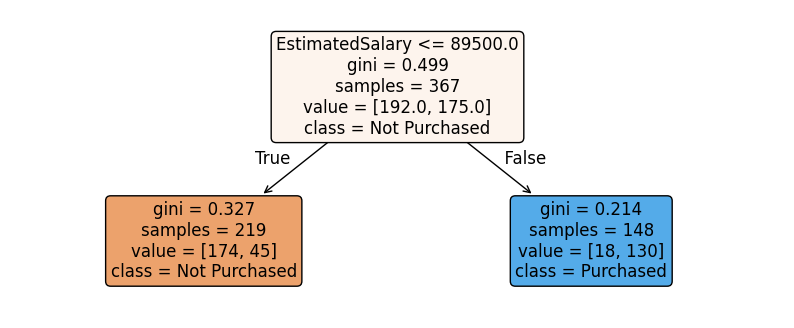

In [338]:
plt.figure(figsize=(10, 4))
plot_tree(dt2, feature_names=['Age', 'EstimatedSalary'], class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True, fontsize=12)
plt.show()

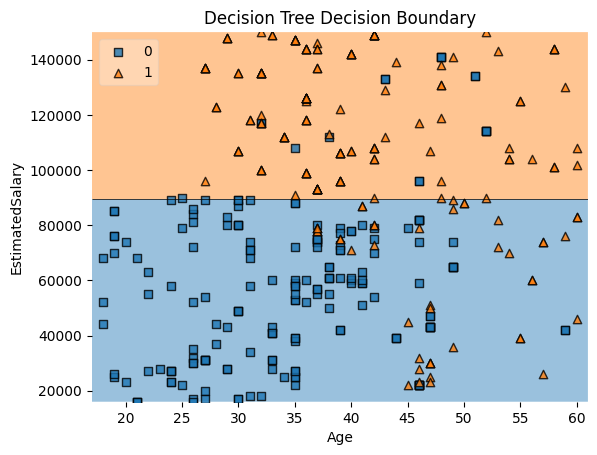

In [339]:
plot_decision_regions(x,y,clf=dt2,legend=2)
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Decision Tree Decision Boundary')
plt.show()

In [340]:
df2['y_pred']=dt2.predict(x)

In [341]:
df2

,Age,EstimatedSalary,Purchased,weights,y_pred
321,41,63000,0,0.002725,0
225,46,82000,0,0.002725,0
201,59,42000,0,0.002725,0
266,48,141000,0,0.002725,1
188,35,22000,0,0.002725,0
...,...,...,...,...,...
189,35,39000,0,0.002725,0
197,40,142000,1,0.002725,1
168,23,28000,0,0.002725,0
236,44,39000,0,0.002725,0


In [342]:
error_2= calculate_error(df2)

In [343]:
alpha_2 = calculate_model_weight(error_2)
alpha_2

np.float64(0.786946458380361)

In [344]:
df2['updated_weights'] = df.apply(lambda row: update_row_weights(row, alpha_2),axis=1)

In [345]:
df2

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights
321,41,63000,0,0.002725,0,0.001240
225,46,82000,0,0.002725,0,0.005986
201,59,42000,0,0.002725,0,0.005986
266,48,141000,0,0.002725,1,0.005986
188,35,22000,0,0.002725,0,0.001240
...,...,...,...,...,...,...
189,35,39000,0,0.002725,0,0.001240
197,40,142000,1,0.002725,1,0.005986
168,23,28000,0,0.002725,0,0.001240
236,44,39000,0,0.002725,0,0.005986
